<a href="https://colab.research.google.com/github/akhila-p-nair/exp1/blob/main/Internet_Data_Usage_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("user_behavior_dataset.csv")
df.head()

,User_ID,Device_Model,Operating_System,App_Usage_Time,Screen_On_Time,Battery_Drain,Number_of_Apps_Installed,Data_Usage,Age,Gender,User_Behavior_Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   700 non-null    int64  
 1   Device_Model              700 non-null    object 
 2   Operating_System          700 non-null    object 
 3   App_Usage_Time            700 non-null    int64  
 4   Screen_On_Time            700 non-null    float64
 5   Battery_Drain             700 non-null    int64  
 6   Number_of_Apps_Installed  700 non-null    int64  
 7   Data_Usage                700 non-null    int64  
 8   Age                       700 non-null    int64  
 9   Gender                    700 non-null    object 
 10  User_Behavior_Class       700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [14]:
df.isnull().sum()

,0
User_ID,0
Device_Model,0
Operating_System,0
App_Usage_Time,0
Screen_On_Time,0
Battery_Drain,0
Number_of_Apps_Installed,0
Data_Usage,0
Age,0
Gender,0


In [16]:
df.describe()

,User_ID,App_Usage_Time,Screen_On_Time,Battery_Drain,Number_of_Apps_Installed,Data_Usage,Age,User_Behavior_Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [18]:
X = df[['App_Usage_Time','Screen_On_Time','Battery_Drain',
        'Number_of_Apps_Installed', 'Age']]

y = df['Data_Usage']

print(X.head())
print(y.head())

   App_Usage_Time  Screen_On_Time  Battery_Drain  Number_of_Apps_Installed  \
0             393             6.4           1872                        67   
1             268             4.7           1331                        42   
2             154             4.0            761                        32   
3             239             4.8           1676                        56   
4             187             4.3           1367                        58   

   Age  
0   40  
1   47  
2   42  
3   20  
4   31  
0    1122
1     944
2     322
3     871
4     988
Name: Data_Usage, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(560, 5)
(140, 5)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 137.1581630780753
MSE: 33022.23290930098
R2 Score: 0.9060865696765592


In [29]:
new_user = [[300, 6.5, 1500, 50, 22]]

prediction = model.predict(new_user)

print("Predicted Internet Data Usage:", round(prediction[0], 2), "MB")

Predicted Internet Data Usage: 1060.04 MB


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


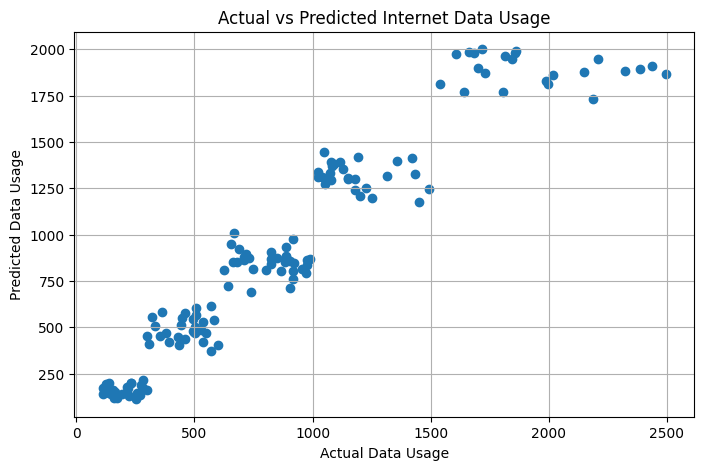

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Data Usage")
plt.ylabel("Predicted Data Usage")
plt.title("Actual vs Predicted Internet Data Usage")
plt.grid(True)
plt.show()

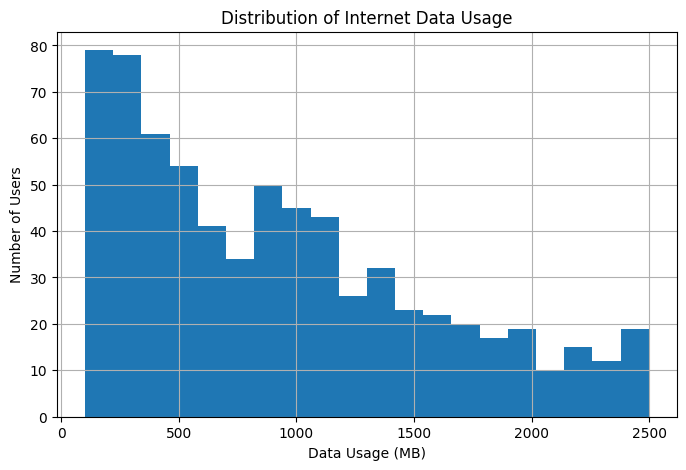

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Data_Usage'], bins=20)
plt.title("Distribution of Internet Data Usage")
plt.xlabel("Data Usage (MB)")
plt.ylabel("Number of Users")
plt.grid(True)
plt.show()